# Task
Perform a PCA on the "Cancer.csv" dataset to identify the first two principal components. Visualize these components in a scatter plot, distinguishing between 'cancer' and 'no-cancer' groups. Finally, summarize the PCA results, including explained variance and group separation.

## Load and Prepare Data

### Subtask:
Load the 'Cancer.csv' dataset into a pandas DataFrame. Identify the features for PCA and the target variable (cancer/no-cancer) for group distinction. Then, standardize the features to ensure proper PCA application.


In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the 'Cancer.csv' file into a pandas DataFrame
df = pd.read_csv('/content/sample_data/Cancer.csv')

# Display the first few rows and information to identify the target column
print('DataFrame head:')
print(df.head())
print('\nDataFrame info:')
print(df.info())

# If the column name is different, this line will need adjustment after inspecting df.info()
if 'diagnosis' in df.columns:
    target_column = 'diagnosis'
elif 'target' in df.columns:
    target_column = 'target'
else:
    target_column = df.columns[-1]

# Identify feature columns (all columns except the target and 'id' if present)
if 'id' in df.columns:
    X = df.drop(columns=[target_column, 'id'])
else:
    X = df.drop(columns=[target_column])

# Identify the target column
y = df[target_column]

# Initialize StandardScaler and fit it to your feature data X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the shape of original and scaled features and the target variable
print(f"\nShape of original features (X): {X.shape}")
print(f"Shape of standardized features (X_scaled): {X_scaled.shape}")
print(f"Shape of target variable (y): {y.shape}")

DataFrame head:
   0.063915  0.033242  0.018484  0.0086177  0.035629  0.037925  0.028865  \
0  0.025409  0.051085  0.056305   0.021738  0.027410  0.014914  0.022455   
1  0.025536  0.036123  0.054195   0.009735  0.027521  0.052255  0.042812   
2  0.012817  0.029652  0.079290   0.050677  0.039737  0.057713  0.044492   
3  0.019846 -0.010577 -0.007504   0.019042  0.068786  0.061764  0.039036   
4  0.039048  0.039355  0.001343   0.026221  0.044091  0.043953  0.039629   

   0.061731    0.0631  0.024787  ...  0.021515  0.017385  0.018564  0.010027  \
0  0.023957  0.060527  0.047382  ...  0.055033  0.080864  0.053423  0.051942   
1  0.069087  0.069873  0.066629  ...  0.033783  0.029022  0.046397  0.033288   
2  0.034581  0.042587  0.034147  ...  0.036083  0.038598  0.048881  0.025569   
3  0.020445  0.025988  0.066716  ...  0.032044  0.026320  0.072016  0.070145   
4  0.047926  0.046892  0.030589  ...  0.065494  0.030681  0.039686  0.037256   

   0.012907  0.023405  0.038839  0.038151  0.0

## Part A: Principal Component Analysis

### Subtask:
Apply Principal Component Analysis (PCA) to the standardized features, extracting the first two principal components (PC1 and PC2).


In [7]:
from sklearn.decomposition import PCA

# Create a PCA instance with 2 components
pca = PCA(n_components=2)

# Fit PCA to the standardized data and transform it
principal_components = pca.fit_transform(X_scaled)

# Display the shape of the principal components
print(f"Shape of principal components: {principal_components.shape}")

# Print the explained variance ratio
print(f"Explained variance ratio of principal components: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2f}")

Shape of principal components: (215, 2)
Explained variance ratio of principal components: [0.22266382 0.08715888]
Total explained variance: 0.31


### Subtask:
Generate a scatter plot of PC1 versus PC2 for all patients. Color the points distinctly based on their 'cancer' or 'no-cancer' group, and include a legend for clear identification of the groups. Label the axes as PC1 and PC2.


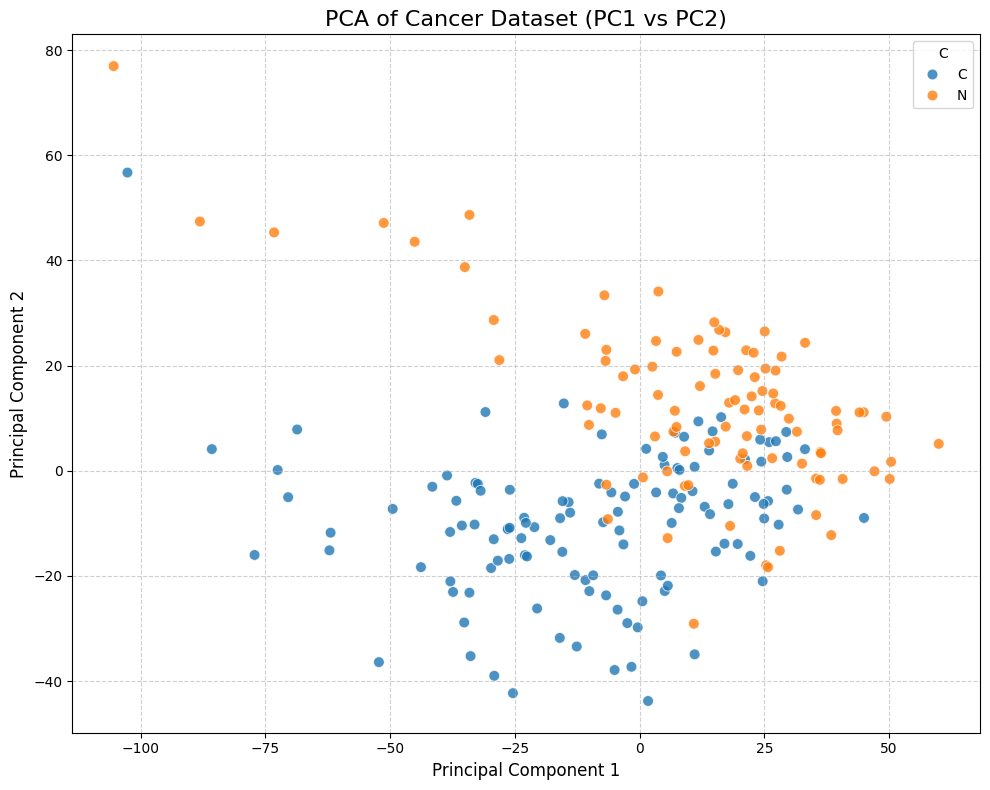

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Add the target variable to the pca_df DataFrame. Reset index of y to align correctly.
pca_df[target_column] = y.reset_index(drop=True)

# Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue=target_column, data=pca_df, s=60, alpha=0.8)

# Add title and labels
plt.title('PCA of Cancer Dataset (PC1 vs PC2)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Display legend
plt.legend(title=target_column)

# Show the plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##Part B: Information Preservation

### Subtask:
Provide a summary of the PCA results, including how well the first two principal components explain the variance, and discuss the visual separation (or lack thereof) between the cancer and no-cancer groups in the scatter plot.


In [9]:
from sklearn.decomposition import PCA

# Create a PCA instance with 10 components
pca_10 = PCA(n_components=10)

# Fit PCA to the standardized data and transform it
principal_components_10 = pca_10.fit_transform(X_scaled)

# Calculate the total explained variance by the first 10 components
total_explained_variance_10_pcs = pca_10.explained_variance_ratio_.sum()

print(f"Total explained variance by the first 10 principal components: {total_explained_variance_10_pcs:.4f} ({total_explained_variance_10_pcs*100:.2f}%)")

Total explained variance by the first 10 principal components: 0.4708 (47.08%)


In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score

# Prepare the data for the ANN
X_ann = principal_components_10 # Use the first 10 principal components

# Encode the target variable 'y' to numerical (0 and 1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_ann, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (150, 10)
X_test shape: (65, 10)
y_train shape: (150,)
y_test shape: (65,)


### Build and Train the ANN Model

In [12]:
from tensorflow.keras.layers import Input

# Define the ANN model with an Input layer
model = Sequential([
    Input(shape=(X_train.shape[1],)), # Explicit Input layer
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train, epochs=50, batch_size=10, validation_split=0.2, verbose=0
)

print("ANN Model Training Complete.")

# Evaluate the model on the test set
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

accuracy = accuracy_score(y_test, y_pred)
print(f"\nANN Classifier Accuracy: {accuracy:.4f}")

ANN Model Training Complete.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

ANN Classifier Accuracy: 0.9846
